In [14]:
import os
from pathlib import Path

import torch
from diffusers import StableDiffusionPipeline

PROJECT_ROOT = Path('/project')
os.chdir(PROJECT_ROOT)

os.environ['WANDB_DISABLED'] = 'true'

print('cwd:', os.getcwd())
print('cuda available:', torch.cuda.is_available())

cwd: /project
cuda available: True


In [2]:
# 실험 공통 설정
NUM_SAMPLES = 1000          # 빠른 실험: 300~600, 더 안정적이면 1000
NUM_TRAIN_EPOCHS = 10      # 빠른 실험용
NUM_TEST_SAMPLES = 6

CONCEPT_NAME = 'purple'
BASE_PROMPT = 'a basketball'
TARGET_PROMPT = 'a purple basketball'
APPLY_PROMPTS = ['a basketball', 'a lemon']

DATA_DIR = PROJECT_ROOT / 'datasets' / CONCEPT_NAME
EXP_DIR = PROJECT_ROOT / 'exps' / f'exp_{CONCEPT_NAME}'

print('DATA_DIR =', DATA_DIR)
print('EXP_DIR  =', EXP_DIR)

DATA_DIR = /project/datasets/purple
EXP_DIR  = /project/exps/exp_purple


In [3]:
import json
from tqdm.auto import tqdm

DATA_DIR.mkdir(parents=True, exist_ok=True)

# 1) labels/test/concept_dict 저장
labels = [
    [[BASE_PROMPT, [CONCEPT_NAME]]]
    for _ in range(NUM_SAMPLES)
]

test_cfg = [BASE_PROMPT, [CONCEPT_NAME]]
concept_dict = {CONCEPT_NAME: 0}

with open(DATA_DIR / 'labels.json', 'w') as f:
    json.dump(labels, f)
with open(DATA_DIR / 'test.json', 'w') as f:
    json.dump(test_cfg, f)
with open(DATA_DIR / 'concept_dict.json', 'w') as f:
    json.dump(concept_dict, f)

print('metadata saved')

# 2) 학습용 이미지 생성 (TARGET_PROMPT)
pipe = StableDiffusionPipeline.from_pretrained('CompVis/stable-diffusion-v1-4')
pipe = pipe.to('cuda')
pipe.safety_checker = None
pipe.set_progress_bar_config(disable=True)

for i in tqdm(range(NUM_SAMPLES), desc='creating images'):
    image = pipe(TARGET_PROMPT, num_inference_steps=30)[0][0]
    image.save(DATA_DIR / f'{i}.jpg')

print('dataset creation done:', DATA_DIR)

# 메모리 정리
try:
    del pipe
    torch.cuda.empty_cache()
except Exception:
    pass

metadata saved


creating images: 100%|██████████| 1000/1000 [55:51<00:00,  3.35s/it]

dataset creation done: /project/datasets/purple


In [16]:
import os
import subprocess

SKIP_TRAIN_IF_EXISTS = True
weight_path = EXP_DIR / 'unet.pth'

if SKIP_TRAIN_IF_EXISTS and weight_path.exists():
    print('skip training, found:', weight_path)
else:
    EXP_DIR.mkdir(parents=True, exist_ok=True)
    cmd = [
        'python', 'train.py',
        '--train_data_dir', str(DATA_DIR),
        '--output_dir', str(EXP_DIR),
        '--num_train_epochs', str(NUM_TRAIN_EPOCHS),
        '--log_every_steps', '500',
        '--log_every_epochs', '2',
        '--report_to', 'tensorboard',
    ]
    env = os.environ.copy()
    env['WANDB_DISABLED'] = 'true'

    print('running:', ' '.join(cmd))
    try:
        subprocess.run(cmd, check=True, env=env)
    except subprocess.CalledProcessError as e:
        print('failed cmd:', e.cmd)
        print('returncode:', e.returncode)

print('trained weight:', weight_path, 'exists=', weight_path.exists())

skip training, found: /project/exps/exp_purple/unet.pth
trained weight: /project/exps/exp_purple/unet.pth exists= True


In [17]:
import os
import subprocess

env = os.environ.copy()
env['WANDB_DISABLED'] = 'true'

for p in APPLY_PROMPTS:
    out_dir_name = p.replace(' ', '_')
    cmd = [
        'python', 'test.py',
        '--train_data_dir', str(DATA_DIR),
        '--output_dir', str(EXP_DIR),
        '--evaluation_type', 'eval',
        '--num_test_samples', str(NUM_TEST_SAMPLES),
        '--prompt', p,
        '--concept', CONCEPT_NAME,
        '--image_dir', f'images_{out_dir_name}',
    ]
    print('running:', ' '.join(cmd))
    subprocess.run(cmd, check=True, env=env)

print('done')
print(f'{APPLY_PROMPTS[0].replace(" ", "_")} images   ->', EXP_DIR / f'images_{APPLY_PROMPTS[0].replace(" ", "_")}')
print(f'{APPLY_PROMPTS[1].replace(" ", "_")} images->', EXP_DIR / f'images_{APPLY_PROMPTS[1].replace(" ", "_")}')

running: python test.py --train_data_dir /project/datasets/purple --output_dir /project/exps/exp_purple --evaluation_type eval --num_test_samples 6 --prompt a basketball --concept purple --image_dir images_a_basketball


/usr/local/lib/python3.10/dist-packages/accelerate/utils/torch_xla.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Num trainable params:  8192000
eval with concept: [['purple']]


100%|██████████| 50/50 [00:05<00:00,  9.54it/s]


running: python test.py --train_data_dir /project/datasets/purple --output_dir /project/exps/exp_purple --evaluation_type eval --num_test_samples 6 --prompt a lemon --concept purple --image_dir images_a_lemon


/usr/local/lib/python3.10/dist-packages/accelerate/utils/torch_xla.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Num trainable params:  8192000
eval with concept: [['purple']]


100%|██████████| 50/50 [00:05<00:00,  9.41it/s]


done
a_basketball images   -> /project/exps/exp_purple/images_a_basketball
a_lemon images-> /project/exps/exp_purple/images_a_lemon


In [18]:
A = EXP_DIR / f'images_{APPLY_PROMPTS[0].replace(" ", "_")}', f'{APPLY_PROMPTS[0]} + {CONCEPT_NAME} concept'
B = EXP_DIR / f'images_{APPLY_PROMPTS[1].replace(" ", "_")}', f'{APPLY_PROMPTS[1]} + {CONCEPT_NAME} concept'

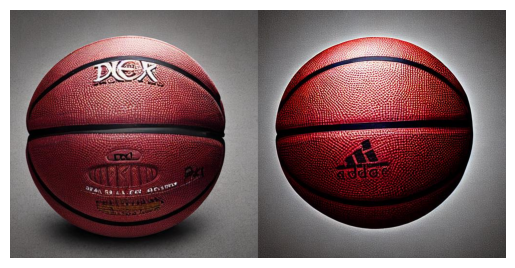

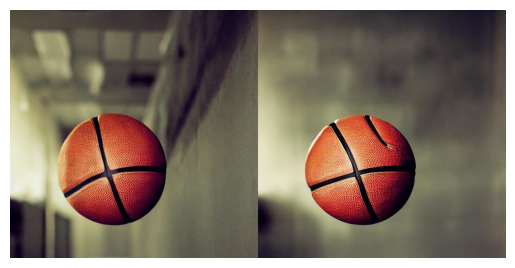

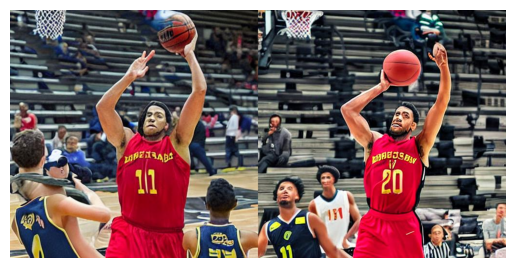

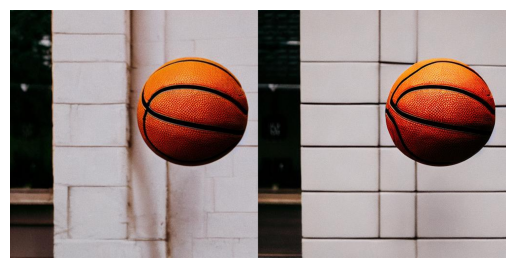

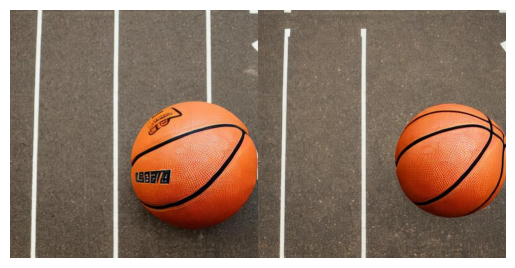

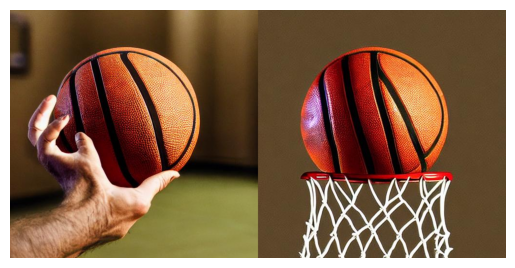

In [19]:
import os
import matplotlib.pyplot as plt

img_dir, desc = A

for f in os.listdir(img_dir):
    img_path = os.path.join(img_dir, f)
    img = plt.imread(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

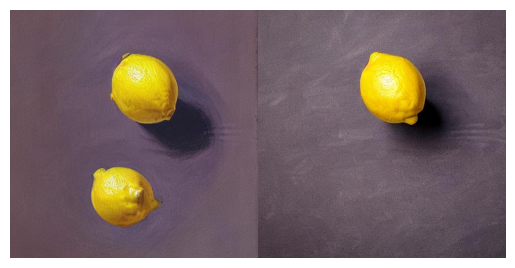

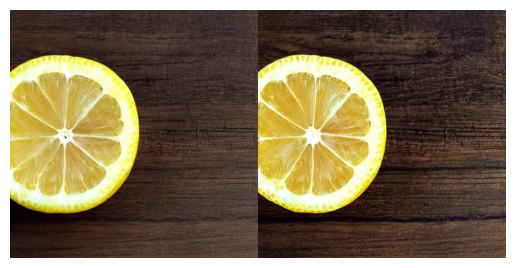

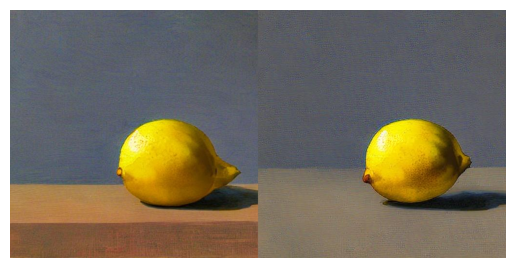

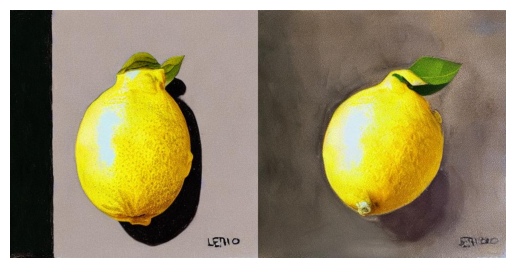

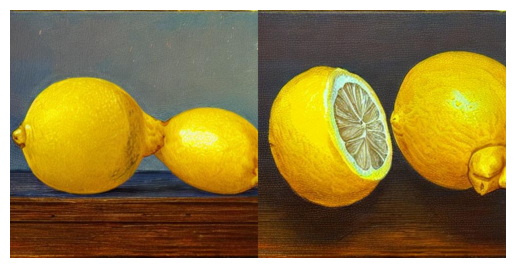

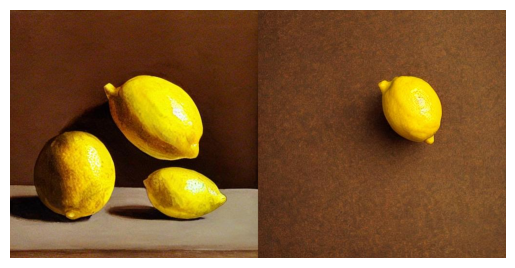

In [20]:
img_dir, desc = B

for f in os.listdir(img_dir):
    img_path = os.path.join(img_dir, f)
    img = plt.imread(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()